In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import scipy.cluster.hierarchy as sch

In [ ]:
df = pd.read_csv("Credit Card Customer Data.csv")
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [ ]:
df=df.drop(['Sl_No', 'Customer Key'], axis=1)

In [ ]:
df.shape

(660, 5)

In [ ]:
df.describe()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000
mean,34574.242424,4.706061,2.403030,2.606061,3.583333
std,37625.487804,2.167835,1.631813,2.935724,2.865317
min,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,48000.000000,6.000000,4.000000,4.000000,5.000000
max,200000.000000,10.000000,5.000000,15.000000,10.000000


In [ ]:
df.duplicated().sum()

np.int64(11)

In [ ]:
df=df.drop_duplicates()
df.shape

(649, 5)

In [ ]:
df.isnull().sum()

,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


In [ ]:
negative_counts=(df < 0).sum()
print("Count of negative values per column:\n",negative_counts)

Count of negative values per column:
 Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64


In [ ]:
for col in df:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = 0
    for value in df[col]:
        if value < lower_bound or value > upper_bound:
            outliers += 1

    print(f"  {col}: {outliers} outliers detected")
    print(f"    Range before: [{df[col].min():.2f}, {df[col].max():.2f}]")

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    print(f"    Range after: [{df[col].min():.2f}, {df[col].max():.2f}]")

  Avg_Credit_Limit: 38 outliers detected
    Range before: [3000.00, 200000.00]
    Range after: [3000.00, 106000.00]
  Total_Credit_Cards: 0 outliers detected
    Range before: [1.00, 10.00]
    Range after: [1.00, 10.00]
  Total_visits_bank: 0 outliers detected
    Range before: [0.00, 5.00]
    Range after: [0.00, 5.00]
  Total_visits_online: 37 outliers detected
    Range before: [0.00, 15.00]
    Range after: [0.00, 8.50]
  Total_calls_made: 0 outliers detected
    Range before: [0.00, 10.00]
    Range after: [0.00, 10.00]


In [ ]:
scaler=StandardScaler()
df_scaled=scaler.fit_transform(df)
df_scaled

array([[ 2.36693579, -1.24708705, -0.86060646, -0.62324389, -1.24844298],
       [ 0.62701493, -0.78670054, -1.47640975,  2.68678297,  1.88123746],
       [ 0.62701493,  1.05484553, -0.86060646,  0.25942994,  0.14252611],
       ...,
       [ 2.57572629,  1.51523205, -0.86060646,  2.68678297, -0.9007007 ],
       [ 2.57572629,  2.43600508, -0.86060646,  2.68678297, -1.24844298],
       [ 2.57572629,  1.97561857, -1.47640975,  2.68678297, -0.55295843]])

In [ ]:
df_preprocessed=pd.DataFrame(df_scaled, columns=df.columns)
df_preprocessed.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,2.366936,-1.247087,-0.860606,-0.623244,-1.248443
1,0.627015,-0.786701,-1.476410,2.686783,1.881237
2,0.627015,1.054846,-0.860606,0.259430,0.142526
3,-0.068953,0.134072,-0.860606,-0.623244,0.142526
4,2.366936,0.594459,-1.476410,2.686783,-0.205216


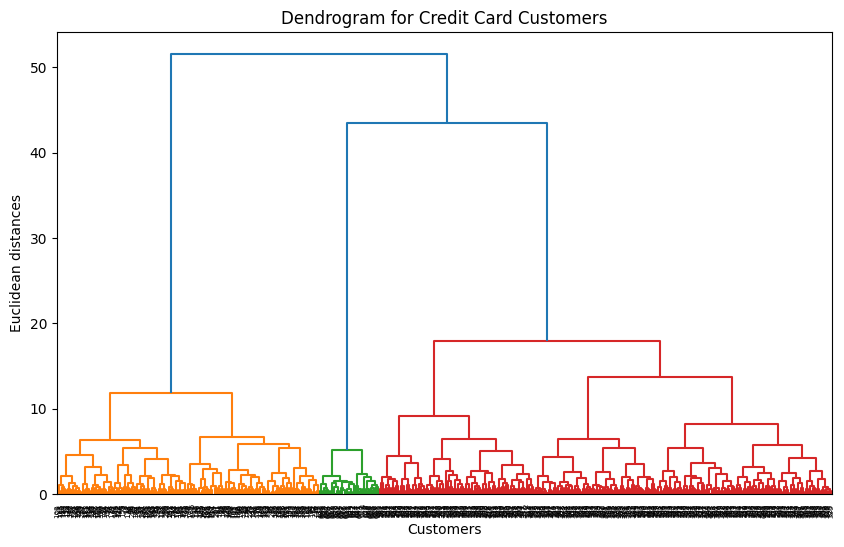

In [ ]:
plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(df_preprocessed, method='ward'))
plt.title('Dendrogram for Credit Card Customers')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [ ]:
hac=AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
clusters=hac.fit_predict(df_scaled)

In [ ]:
df['Cluster']=clusters

In [ ]:
silh_score=silhouette_score(df_preprocessed, clusters)
ch_score=calinski_harabasz_score(df_preprocessed, clusters)
db_score=davies_bouldin_score(df_preprocessed, clusters)
print(f"Silhouette Score: {silh_score:.4f} (Higher is better, closer to 1)")
print(f"Calinski-Harabasz Index: {ch_score:.4f} (Higher is better)")
print(f"Davies-Bouldin Index: {db_score:.4f} (Lower is better, closer to 0)")

Silhouette Score: 0.5182 (Higher is better, closer to 1)
Calinski-Harabasz Index: 753.1677 (Higher is better)
Davies-Bouldin Index: 0.6665 (Lower is better, closer to 0)


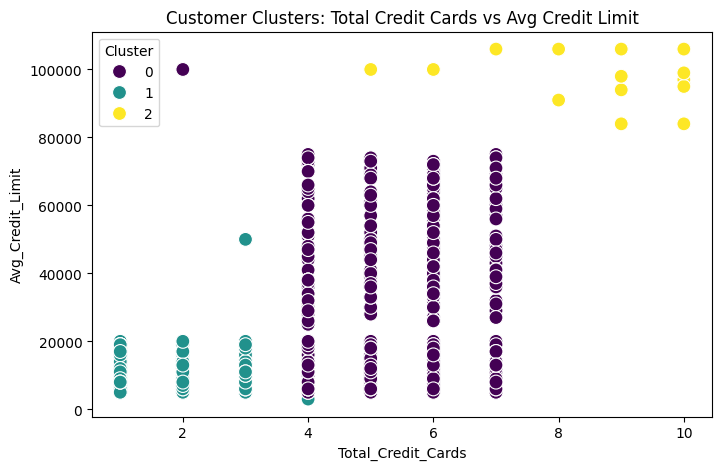

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='Total_Credit_Cards',
    y='Avg_Credit_Limit',
    hue='Cluster',
    data=df,
    palette='viridis',
    s=100
)
plt.title('Customer Clusters: Total Credit Cards vs Avg Credit Limit')
plt.show()